# Boligpris- og Konsumprisindeks

Bustadmarknaden er ein sentral del av norsk økonomi,
og bustadprisane har auka mykje over dei siste tiåra.
Samstundes vert kjøpekraften påverka av av generell prisstiging i økonomien,
målt gjennom konsumprisindeksen (KPI).
For bustadkjøparar er det difor interessant å forstå ikkje berre nominell
prisutvikling, men òg korleis boligprisane utviklar seg relativt til 
inflasjonen.

Me skal ta for oss fylgjande problemstilling:

> Korleis har boligprisane i Noreg utvikla seg samanlikna med 
konsumprisindeksen, og kva seier dette om reell prisvekst i bustadmarknaden?

## Datasett for bustadprisar

Eg har lasta ned datasettet [1060.csv](./1060.csv) frå
Statistisk sentralbyrå med informasjon om bustadprisindeksen.
Datasettet startar på 1992K1 fordi Statistisk sentralbyrå tok til
å publisera prisindeksar for brukte sjølveigarbustadar tidleg på
1990-tallet, etter kraftige prisfall i bustadmarknaden på slutten
av 1980- og starten av 1990-tallet.
Dette gjev ei historisk oversikt over bustadprisutviklinga i lander
frå ei tid med store marknadsendringar.

In [1]:
import pandas as pd

df1 = pd.read_csv("1060.csv", sep=";", encoding="latin1")
display(df1)

,region,boligtype,kvartal,statistikkvariabel,"07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel"
0,TOTAL Hele landet,00 Alle boligtyper,1992K1,Prisindeks for brukte boliger,"18,8"
1,TOTAL Hele landet,00 Alle boligtyper,1992K1,"Prisindeks for brukte boliger, sesongjustert",..
2,TOTAL Hele landet,00 Alle boligtyper,1992K2,Prisindeks for brukte boliger,"18,9"
3,TOTAL Hele landet,00 Alle boligtyper,1992K2,"Prisindeks for brukte boliger, sesongjustert",..
4,TOTAL Hele landet,00 Alle boligtyper,1992K3,Prisindeks for brukte boliger,19
...,...,...,...,...,...
12955,011 Nord-Norge,03 Blokkleiligheter,2025K1,"Prisindeks for brukte boliger, sesongjustert",..
12956,011 Nord-Norge,03 Blokkleiligheter,2025K2,Prisindeks for brukte boliger,"153,6"
12957,011 Nord-Norge,03 Blokkleiligheter,2025K2,"Prisindeks for brukte boliger, sesongjustert",..
12958,011 Nord-Norge,03 Blokkleiligheter,2025K3,Prisindeks for brukte boliger,"154,1"


Me har lasta inn datasettet i pandas, og utskrifta viser at me kan fylgja
bustadprisindeksen kvartal for kvartal.  Me ser derimot at der er fleire tidsrekkjer i datasettet, for ulike regionar og ulike bustadtypar. For å sjå utviklinga, må me sjå på tidsrekkjene kvar for seg.  Det kjem me tilbake til. Det andre problemet me må sjekka er datatypane.  Tidssøylen ser ut til å vera strengar, og me må sjekka at prisindeksen er tal.

In [2]:
df1.dtypes

region                                                                                          str
boligtype                                                                                       str
kvartal                                                                                         str
statistikkvariabel                                                                              str
07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel    str
dtype: object

Her er alle søylene strengar, og det er ikkje bra.
Lat oss ta prisindeksen fyrst.  Han er vist med desimalkomma, og ikkje punktum som i engelskspråklege system.  
Me ser òg nokre radar med `..` for indeks.  Det tyder sikkert at data manglar.
Dette kunne me ha fiksa då me las fila, so lat oss gjera det på nytt.

In [3]:
df1 = pd.read_csv("1060.csv", sep=";"
                  , encoding="latin1"
                  , decimal=","
                  , na_values="..")
display(df1.head())

,region,boligtype,kvartal,statistikkvariabel,"07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel"
0,TOTAL Hele landet,00 Alle boligtyper,1992K1,Prisindeks for brukte boliger,"18,8"
1,TOTAL Hele landet,00 Alle boligtyper,1992K1,"Prisindeks for brukte boliger, sesongjustert",NaN
2,TOTAL Hele landet,00 Alle boligtyper,1992K2,Prisindeks for brukte boliger,"18,9"
3,TOTAL Hele landet,00 Alle boligtyper,1992K2,"Prisindeks for brukte boliger, sesongjustert",NaN
4,TOTAL Hele landet,00 Alle boligtyper,1992K3,Prisindeks for brukte boliger,19


Dette ser betre ut. Me har brukt `decimal` for å velja desimalskiljeteikn og `na_values` for å seia korleis manglande data er representert.
Det er likevel ikkje godt nok, når me ser på datatypane.

In [4]:
df1.dtypes

region                                                                                          str
boligtype                                                                                       str
kvartal                                                                                         str
statistikkvariabel                                                                              str
07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel    str
dtype: object

Prisindeksen er stadig ein streng.  Der må dermed vera fleire verdiar som pandas ikkje kan lesa som tal.
Det viser seg at manglande verdi somme plassar er registrert med eitt punktum.

In [5]:
df1 = pd.read_csv("1060.csv", sep=";"
                  , encoding="latin1"
                  , decimal=","
                  , na_values=[ "..", "." ])
display(df1.head())

,region,boligtype,kvartal,statistikkvariabel,"07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel"
0,TOTAL Hele landet,00 Alle boligtyper,1992K1,Prisindeks for brukte boliger,18.8
1,TOTAL Hele landet,00 Alle boligtyper,1992K1,"Prisindeks for brukte boliger, sesongjustert",NaN
2,TOTAL Hele landet,00 Alle boligtyper,1992K2,Prisindeks for brukte boliger,18.9
3,TOTAL Hele landet,00 Alle boligtyper,1992K2,"Prisindeks for brukte boliger, sesongjustert",NaN
4,TOTAL Hele landet,00 Alle boligtyper,1992K3,Prisindeks for brukte boliger,19.0


No vert tala skrivne med punktum, slik dei skal når pandas forstår dei som tal.
For å dobbelsjekka, ser me typane.

In [6]:
df1.dtypes

region                                                                                              str
boligtype                                                                                           str
kvartal                                                                                             str
statistikkvariabel                                                                                  str
07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel    float64
dtype: object

::: {admonition} Refleksjon
Dette vart overdrive tungvint.  
Det hadde vore enklare å bruke *string replace* for å byta ut komma med punktum, for så å byta type med `.astype(float64)`.
Direkte lesing med `read_csv()` er meir elegant som endeleg løysing, men det er ikkje lett å identifisera alle notasjonane for manglande data.
:::

### Tidsaksa

Tidssøylen er òg strengar.
For å retta det, må me fyrste byta ut `K` med `Q` som pandas
kjenner att som kvartal, og dernest omsetja heile søyla til
`PeriodIndex` som gjev tidsintervall i pandas.

Me lagar ein kopi av vår *DataFrame* for å unngå kluss om me
må gå tilbake og køyra koden på nytt.

In [7]:
def formatertid(streng):
    return streng.replace("K", "Q")
    
df2 = df1.copy()
df2["kvartal"] = df2["kvartal"].map(formatertid)
df2["kvartal"] = pd.PeriodIndex(df2["kvartal"], freq="Q")
display( df2 )
display( df2.dtypes )

,region,boligtype,kvartal,statistikkvariabel,"07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel"
0,TOTAL Hele landet,00 Alle boligtyper,1992Q1,Prisindeks for brukte boliger,18.8
1,TOTAL Hele landet,00 Alle boligtyper,1992Q1,"Prisindeks for brukte boliger, sesongjustert",NaN
2,TOTAL Hele landet,00 Alle boligtyper,1992Q2,Prisindeks for brukte boliger,18.9
3,TOTAL Hele landet,00 Alle boligtyper,1992Q2,"Prisindeks for brukte boliger, sesongjustert",NaN
4,TOTAL Hele landet,00 Alle boligtyper,1992Q3,Prisindeks for brukte boliger,19.0
...,...,...,...,...,...
12955,011 Nord-Norge,03 Blokkleiligheter,2025Q1,"Prisindeks for brukte boliger, sesongjustert",NaN
12956,011 Nord-Norge,03 Blokkleiligheter,2025Q2,Prisindeks for brukte boliger,153.6
12957,011 Nord-Norge,03 Blokkleiligheter,2025Q2,"Prisindeks for brukte boliger, sesongjustert",NaN
12958,011 Nord-Norge,03 Blokkleiligheter,2025Q3,Prisindeks for brukte boliger,154.1


region                                                                                                    str
boligtype                                                                                                 str
kvartal                                                                                         period[Q-DEC]
statistikkvariabel                                                                                        str
07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel          float64
dtype: object

No er kvartal registrert som tidsperiodar.
Til sist skal me gjera kvartalsøyla til indeks, slik at me slipp
å spesifisera $x$-aksa når me går vidare.

In [8]:
df2 = df2.set_index( df2["kvartal"] )
display( df2 )

,region,boligtype,kvartal,statistikkvariabel,"07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel"
kvartal,,,,,
1992Q1,TOTAL Hele landet,00 Alle boligtyper,1992Q1,Prisindeks for brukte boliger,18.8
1992Q1,TOTAL Hele landet,00 Alle boligtyper,1992Q1,"Prisindeks for brukte boliger, sesongjustert",NaN
1992Q2,TOTAL Hele landet,00 Alle boligtyper,1992Q2,Prisindeks for brukte boliger,18.9
1992Q2,TOTAL Hele landet,00 Alle boligtyper,1992Q2,"Prisindeks for brukte boliger, sesongjustert",NaN
1992Q3,TOTAL Hele landet,00 Alle boligtyper,1992Q3,Prisindeks for brukte boliger,19.0
...,...,...,...,...,...
2025Q1,011 Nord-Norge,03 Blokkleiligheter,2025Q1,"Prisindeks for brukte boliger, sesongjustert",NaN
2025Q2,011 Nord-Norge,03 Blokkleiligheter,2025Q2,Prisindeks for brukte boliger,153.6
2025Q2,011 Nord-Norge,03 Blokkleiligheter,2025Q2,"Prisindeks for brukte boliger, sesongjustert",NaN


### Filtrering

Dette siste steget i datavasken er å sortera variabelane frå kvarandre.
For å gjera det enkelt, skal me berre sjå på heile landet og alle
bustadtypar.  Me ser òg i datasettet at dei sesongjusterte tala ofte
manglar, og me held oss difor til variabelen som heiter
«Prisindeks for brukte boliger».

In [9]:
bpi = df2[df2["statistikkvariabel"] == "Prisindeks for brukte boliger"]
bpi = bpi[bpi["boligtype"] == "00 Alle boligtyper"]
bpi = bpi[bpi["region"] == "TOTAL Hele landet"]
bpi = bpi.copy()
display(bpi)

,region,boligtype,kvartal,statistikkvariabel,"07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel"
kvartal,,,,,
1992Q1,TOTAL Hele landet,00 Alle boligtyper,1992Q1,Prisindeks for brukte boliger,18.8
1992Q2,TOTAL Hele landet,00 Alle boligtyper,1992Q2,Prisindeks for brukte boliger,18.9
1992Q3,TOTAL Hele landet,00 Alle boligtyper,1992Q3,Prisindeks for brukte boliger,19.0
1992Q4,TOTAL Hele landet,00 Alle boligtyper,1992Q4,Prisindeks for brukte boliger,18.5
1993Q1,TOTAL Hele landet,00 Alle boligtyper,1993Q1,Prisindeks for brukte boliger,17.8
...,...,...,...,...,...
2024Q3,TOTAL Hele landet,00 Alle boligtyper,2024Q3,Prisindeks for brukte boliger,145.9
2024Q4,TOTAL Hele landet,00 Alle boligtyper,2024Q4,Prisindeks for brukte boliger,143.0
2025Q1,TOTAL Hele landet,00 Alle boligtyper,2025Q1,Prisindeks for brukte boliger,150.9


No har me éi isolert tidsrekkje i datasettet.  Dette gjer at dei tre
søylene med variabelnamn vert overflødige, og me kan ta dei bort.

In [10]:
idxs_bpi = list(bpi.columns)
print( idxs_bpi )

['region', 'boligtype', 'kvartal', 'statistikkvariabel', '07221: Prisindeks for brukte boliger, etter region, boligtype, kvartal og statistikkvariabel']


Me skal fjerna søyle 0-3 og byta namn på nr. 4.

In [11]:
bpi = bpi.drop(labels=idxs_bpi[0:4], axis=1)
bpi = bpi.rename(columns={ idxs_bpi[4] : "BPI" })
display(bpi)

,BPI
kvartal,
1992Q1,18.8
1992Q2,18.9
1992Q3,19.0
1992Q4,18.5
1993Q1,17.8
...,...
2024Q3,145.9
2024Q4,143.0
2025Q1,150.9


Denne tidsrekkja kan me plotta.

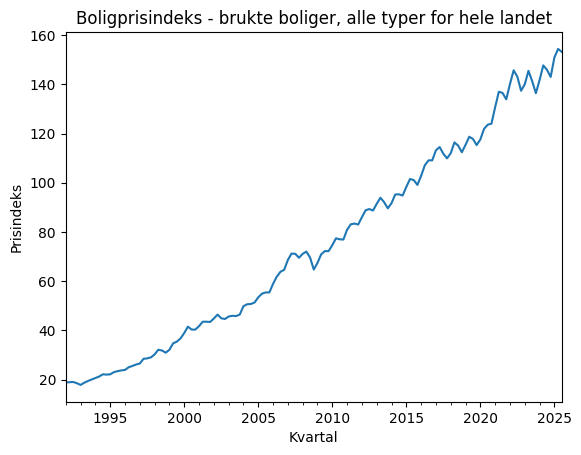

In [12]:
import matplotlib.pyplot as plt
bpi["BPI"].plot(title="Boligprisindeks - brukte boliger, alle typer for hele landet")
plt.xlabel("Kvartal")
plt.ylabel("Prisindeks")
plt.show()

### Prosentvis endring

Vidare kan det vera interessant å sjå kva kvartal som hadde høgast og
lågast **prosentvis endring**.
Me kan laga ei ny søyle med metoden `pct_change()`, som reknar ut
prosentvis endring frå førre periode.
Me gangar med hundre for å sjå prosentpoeng.

In [13]:
bpi["vekst"] = bpi["BPI"].pct_change() * 100
display(bpi)

,BPI,vekst
kvartal,,
1992Q1,18.8,NaN
1992Q2,18.9,0.531915
1992Q3,19.0,0.529101
1992Q4,18.5,-2.631579
1993Q1,17.8,-3.783784
...,...,...
2024Q3,145.9,-1.218687
2024Q4,143.0,-1.987663
2025Q1,150.9,5.524476


Fyrste periode har sjølvsagt NaN, sidan der ikkje finst nokon tidlegare
periode å samanlikna med.
Elles ser tala ut som rimelege prosenttal.

In [14]:
lav_endring = bpi["vekst"].idxmin()
lav_endring_verdi = bpi["vekst"].min()
print(f"Kvartalet med lavest prisvekst var {lav_endring}, med en endring på {lav_endring_verdi:.1f}%")

Kvartalet med lavest prisvekst var 2008Q4, med en endring på -7.0%


Det verkar rimeleg.  Siste kvartal 2008 var midt i finanskrisen, og eit
sjelden tilfelle av prisnedgang.

Me har brutk f-strengar for lett å kunna bestemma talet på desimalplassar,
her med `.1f` for å få éin desimal.

In [15]:
hoy_endring = bpi["vekst"].idxmax()
hoy_endring_verdi = bpi["vekst"].max()
print(f"Kvartalet med høyest prisvekst var {hoy_endring}, med en endring på {hoy_endring_verdi:.1f}%")

Kvartalet med høyest prisvekst var 1999Q2, med en endring på 8.1%


Kvartalet med høgast prosentvis prisvekst i BPI var andre kvartal 1999,
med ei auke på 8,1%.
Dette kan ha vore drive av høg etterspurnad etter bustad, låge renter 
og generelt optimistiske økonomiske utsikter på slutten av 1990-tallet.  

Kvartalet med lavest prisvekst var siste kvartal i 2008, med en nedgang på 7,0%. Dette kvartalet sammenfaller med finanskrisen, som førte til økt usikkerhet i økonomien, strammere kredittforhold og lavere kjøpekraft, som alle bidro til fall i boligprisene.  

Dette viser at kvartalsvise svingninger i boligprisene ofte reflekterer større samfunnsøkonomiske hendelser, og at den reelle prisveksten i boligmarkedet påvirkes av både kortsiktige og langsiktige faktorer som renter, kreditt og økonomisk tillit.

## Datasett for Konsumprisindeks

For å studera konsumprisindeksen har me lasta ned datasettet
[1086.csv](1086.csv) frå SSB.
Dette skal me lesa og formattera på same måte som det fyrste 
datasettet.

In [16]:
kpi0 = pd.read_csv("1086.csv", sep=";"
                  , encoding="latin1"
                  , decimal=","
                  , na_values=[ "..", "." ])
display(kpi0)
display(kpi0.dtypes)

,konsumgruppe,måned,statistikkvariabel,"03013: Konsumprisindeks, etter konsumgruppe, måned og statistikkvariabel"
0,TOTAL Totalindeks,1979M01,Konsumprisindeks (2015=100),25.3
1,TOTAL Totalindeks,1979M01,Månedsendring (prosent),0.0
2,TOTAL Totalindeks,1979M01,12-måneders endring (prosent),5.9
3,TOTAL Totalindeks,1979M02,Konsumprisindeks (2015=100),25.4
4,TOTAL Totalindeks,1979M02,Månedsendring (prosent),0.4
...,...,...,...,...
1678,TOTAL Totalindeks,2025M08,Månedsendring (prosent),-0.6
1679,TOTAL Totalindeks,2025M08,12-måneders endring (prosent),3.5
1680,TOTAL Totalindeks,2025M09,Konsumprisindeks (2015=100),138.5
1681,TOTAL Totalindeks,2025M09,Månedsendring (prosent),0.4


konsumgruppe                                                                    str
måned                                                                           str
statistikkvariabel                                                              str
03013: Konsumprisindeks, etter konsumgruppe, måned og statistikkvariabel    float64
dtype: object

Her fekk me til prisindekssøyla på fyrste forsøk.
Neste steg er å fiksa tidsaksa.  Det gjer me på same måte som sist, men meir kompakt.

In [17]:
kpi1 = kpi0.copy()
kpi1["måned"] = kpi1["måned"].str.replace("M","-")
kpi1["måned"] = pd.PeriodIndex(kpi1["måned"], freq="M")
kpi1 = kpi1.set_index( kpi1["måned"] )
display( kpi1 )
display( kpi1.dtypes )

,konsumgruppe,måned,statistikkvariabel,"03013: Konsumprisindeks, etter konsumgruppe, måned og statistikkvariabel"
måned,,,,
1979-01,TOTAL Totalindeks,1979-01,Konsumprisindeks (2015=100),25.3
1979-01,TOTAL Totalindeks,1979-01,Månedsendring (prosent),0.0
1979-01,TOTAL Totalindeks,1979-01,12-måneders endring (prosent),5.9
1979-02,TOTAL Totalindeks,1979-02,Konsumprisindeks (2015=100),25.4
1979-02,TOTAL Totalindeks,1979-02,Månedsendring (prosent),0.4
...,...,...,...,...
2025-08,TOTAL Totalindeks,2025-08,Månedsendring (prosent),-0.6
2025-08,TOTAL Totalindeks,2025-08,12-måneders endring (prosent),3.5
2025-09,TOTAL Totalindeks,2025-09,Konsumprisindeks (2015=100),138.5


konsumgruppe                                                                      str
måned                                                                       period[M]
statistikkvariabel                                                                str
03013: Konsumprisindeks, etter konsumgruppe, måned og statistikkvariabel      float64
dtype: object

Som i det fyrste datasettet har me her mange statistikkvariablar.
Denne gongen er dei målte månadleg, heller enn kvartalsvis, og
går tilbake til 1979.

Me vil berre studera sjølve konsumprisindeksen.
Me filtrerer òg bort data frå før starten på bustadprisindeksen.

In [18]:
kpi2 = kpi1[kpi1["statistikkvariabel"] == "Konsumprisindeks (2015=100)"]
kpi2 = kpi2[kpi2["måned"] >= pd.Period("1992-01",freq="M") ]
kpi2 = kpi2.copy()
display( kpi2 )

,konsumgruppe,måned,statistikkvariabel,"03013: Konsumprisindeks, etter konsumgruppe, måned og statistikkvariabel"
måned,,,,
1992-01,TOTAL Totalindeks,1992-01,Konsumprisindeks (2015=100),62.4
1992-02,TOTAL Totalindeks,1992-02,Konsumprisindeks (2015=100),62.6
1992-03,TOTAL Totalindeks,1992-03,Konsumprisindeks (2015=100),63.1
1992-04,TOTAL Totalindeks,1992-04,Konsumprisindeks (2015=100),63.3
1992-05,TOTAL Totalindeks,1992-05,Konsumprisindeks (2015=100),63.4
...,...,...,...,...
2025-05,TOTAL Totalindeks,2025-05,Konsumprisindeks (2015=100),137.5
2025-06,TOTAL Totalindeks,2025-06,Konsumprisindeks (2015=100),137.8
2025-07,TOTAL Totalindeks,2025-07,Konsumprisindeks (2015=100),138.9


Dette ser riktig ut, med riktig tidsintervall og berre éin statistikkvariabel.
Me kan droppa overflødige søyler, og laga kortare søylenamn, på same måte som før.

In [19]:
idxs_bpi = list(kpi2.columns)
kpi = kpi2.drop(labels=idxs_bpi[0:3], axis=1)
kpi = kpi.rename(columns={ idxs_bpi[3] : "KPI" })
display(kpi)

,KPI
måned,
1992-01,62.4
1992-02,62.6
1992-03,63.1
1992-04,63.3
1992-05,63.4
...,...
2025-05,137.5
2025-06,137.8
2025-07,138.9


Me kan merka oss at *basisåret* er 2015, dvs. det er her indeksen er 100.
For at KPI og BPI skal vera samanliknbare, bør dei ha same basisår.
Me kan sjekka kvar som er basisåret for BPI med fylgjande kode.

In [20]:
bpi_per_aar = bpi["BPI"].groupby(bpi.index.year).mean()
basisaar = (bpi_per_aar - 100).abs().idxmin()
print(f"Basisåret er {basisaar}, med en gjennomsnittlig prisindeks på {bpi_per_aar.loc[basisaar]:.1f}")

Basisåret er 2015, med en gjennomsnittlig prisindeks på 100.0


::: {admonition} Forklaring
Koden beregner **gjennomsnittlig boligprisindeks per år** ved å gruppere kvartalsdataene i `bpi` etter år med `groupby(bpi.index.year)` og finne gjennomsnittet med `.mean()`. 
Variabelen `bpi_per_aar` inneholder dermed ett gjennomsnittstall for hvert år. 
Deretter finner koden hvilket år som har en gjennomsnittlig prisindeks nærmest 100 med ved å rekna avviket frå 100 
som `(bpi_per_aar - 100).abs()`, og til slutt finna det lågaset avviket med `.idxmin()`.
Dette vert lagra  som `basisaar`. 
Koden stadfestar at basisåret for BPI er 2015 akkurat som for KPI.
:::

Me kan dobbelsjekka at me ikkje har rota det til ved å lista BPI i 2015.

In [21]:
display( bpi[ bpi.index.year == 2015 ] )

,BPI,vekst
kvartal,,
2015Q1,98.3,3.691983
2015Q2,101.5,3.255341
2015Q3,101.1,-0.394089
2015Q4,99.1,-1.978239


Her ser me tal rundt 100 som venta.  Me kan rekna gjennomsnittet for hand for å sjå at det er akkurat 100.

### Plott

Det er alltid nyttig å plotta for å sjekka at datasetta fungerer som dei
skal.

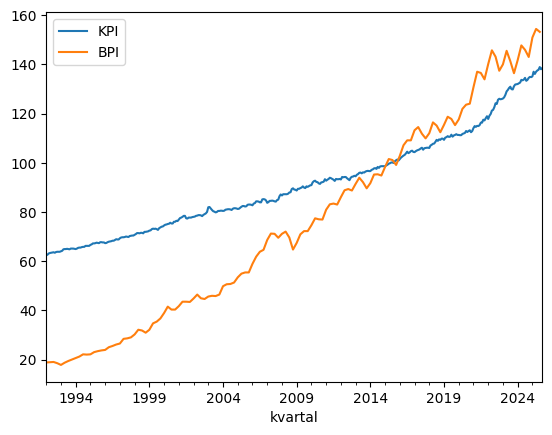

In [22]:
ax = kpi.plot(  )
bpi["BPI"].plot( ax=ax, label="BPI" )
plt.legend()

Legg merke til korleis me må lagra aksesystemet `ax` når me plottar den fyrste rekkja, slik at me kan be om å få den andre i same aksesystem.

Her ser me det som me eigentleg veit.  Bustadprisar veks raskare enn andre prisar, særleg før finanskrisa rundt 2008.

### Kvartalsvis samanlikning

Som nemnd har me månadlege KPI-data og kvartalsvise BPI-data.
For å samanlikna numerisk, er det enklast å ha alt med same
oppløysing.
Me kan gruppera data kvartalsvis og rekna gjennomsnitt per period,
slik.

In [23]:
kpi["kvartal"] = pd.PeriodIndex(kpi.index, freq="Q")

kpi_kvartal = kpi.groupby("kvartal").mean()

display(kpi_kvartal.round(2))

,KPI
kvartal,
1992Q1,62.70
1992Q2,63.40
1992Q3,63.57
1992Q4,63.80
1993Q1,64.33
...,...
2024Q3,133.83
2024Q4,134.73
2025Q1,136.07


::: {admonition} Refleksjon
Teknikken for å gruppera data i lengre periodar er den same som 
me brukte for å sjekka basisåret for indeksen tidlegare, men her
tek me vare på heile tidsrekkja med gjennomsnittleg indeks per
kvartal.
:::

Det er alltid greitt å plotta for å sjekka at alt er rett.

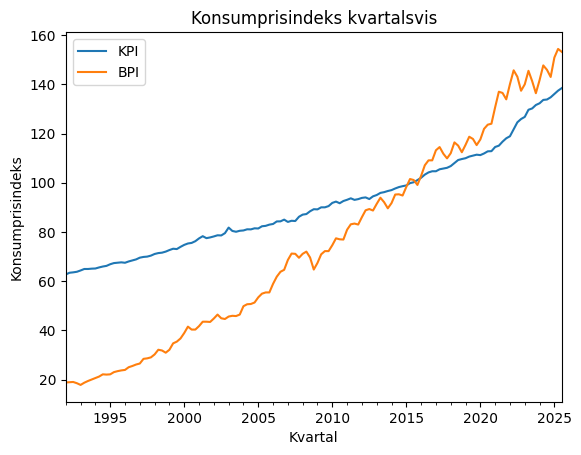

In [24]:
ax = kpi_kvartal["KPI"].plot(title="Konsumprisindeks kvartalsvis", legend="KPI")
bpi["BPI"].plot( ax=ax, legend="BPI" )
plt.xlabel("Kvartal")
plt.ylabel("Konsumprisindeks")
plt.show()

Dette plottet er omtrent likt det forrige, men KPI-kurva er glattare fordi kvart målepunkt er gjennomsnitt over ein lengre periode.
Det er som det skal vera.

## Fletting av datasett

Når me går vidare er det greitt å ha alle data i éin
*DataFrame*.  Det ordnar me med `merge()`.

In [25]:
df = pd.merge(bpi, kpi_kvartal, how='outer', on="kvartal")
display(df.round(2))

,BPI,vekst,KPI
kvartal,,,
1992Q1,18.8,NaN,62.70
1992Q2,18.9,0.53,63.40
1992Q3,19.0,0.53,63.57
1992Q4,18.5,-2.63,63.80
1993Q1,17.8,-3.78,64.33
...,...,...,...
2024Q3,145.9,-1.22,133.83
2024Q4,143.0,-1.99,134.73
2025Q1,150.9,5.52,136.07


Me må presisera at indekssøyla `kvartal` vert brukt til fletting.
Me har òg spesifisert `outer`, som
tyder at alle data kjem me, og manglande data i eitt av 
datasetta vert fyllte inn med NaN.

Text(0, 0.5, 'Prisindeks')

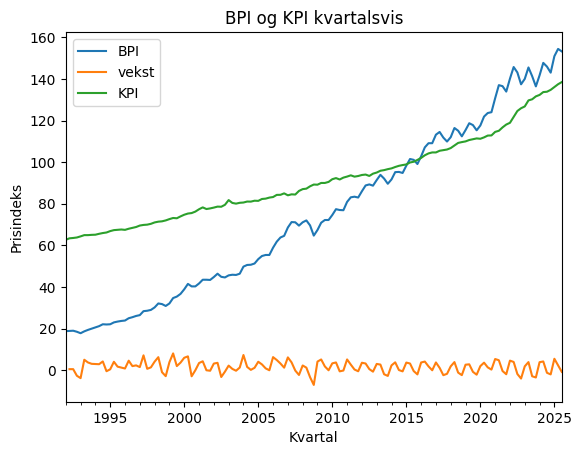

In [26]:
df.plot(title="BPI og KPI kvartalsvis")
plt.xlabel("Kvartal")
plt.ylabel("Prisindeks")

Plottet er det same som før bortsett frå at me plottar alle søylene
og dermed får med prosentvis vekst for BPI.

::: {admonition} Refleksjon
Ved å fletta tidsrekkjene saman i éi *DataFrame* vert koden for å
plotta enklare.  Me treng berre éi line for å plotta alt.
:::

Plottet viser at boligprisane (BPI) ikkje berre veks raskare
men er òg meir **volatile**; dei går ein del opp og ned sjølv
om trenden er opp.
Konsumprisindeksen (KPI) stig **jamnare** over tid.
Boligmarkedet har større svingingar enn generelle konsumprisar.

## Korrelasjon

Videre kan man lage et **spredringsplott** for å se om det er en **korrelasjon** mellom de to indeksene.

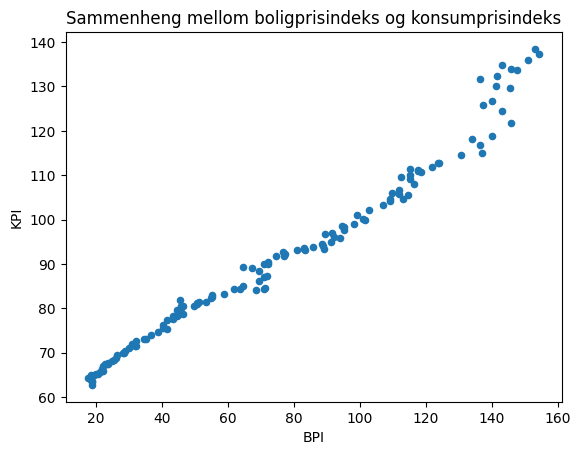

In [27]:
df.plot.scatter("BPI", "KPI")
plt.title("Sammenheng mellom boligprisindeks og konsumprisindeks")
plt.xlabel("BPI")
plt.ylabel("KPI")
plt.show()

I staden for å plotta tidsrekkjene mot tidsaksa, viser spreidingsplottet
dei to indeksane på kvar sin akse.
Kvar prikk i plottet representerer eit kvartal, men tidspunktet for kvart
punkt er ikkje synleg.

Her ser me svært sterk og konsekvent korrelasjon fram til pandemien.
Der er stadig høg korrelasjon dei siste åra, men biletet er mindre
konsekvent.
Det er neppe overraskande.

Dette kan kvantifiseres ved å beregne **korrelasjonen** mellom de to indeksene, og man kan også se på **kovariansen** for å måle hvordan de endrer seg i forhold til hverandre.

In [28]:
indekser = df[["BPI", "KPI"]]

korrelasjon = indekser.corr()
print("Korrelasjon mellom BPI og KPI:")
print(korrelasjon)

Korrelasjon mellom BPI og KPI:
          BPI       KPI
BPI  1.000000  0.986748
KPI  0.986748  1.000000


Koden velger først kolonnene `"boligprisindeks"` og `"konsumprisindeks"` fra datasettet `df` for å kunne sammenligne dem.
Deretter beregnes *korrelasjonskoeffisient* (Pearson) med `.corr()`,
som viser hvor tett BPI og KPI beveger seg sammen.
En verdi nær 1 indikerer sterk positiv korrelasjon,
dvs. at når konsumprisindeksen stiger, stiger også boligprisindeksen.  


Me kan ogso rekna ut kovariansen.

In [29]:
kovarians = indekser.cov()
print("\nKovarians mellom BPI og KPI:")
print(kovarians)


Kovarians mellom BPI og KPI:
             BPI         KPI
BPI  1685.207354  813.335444
KPI   813.335444  403.156664


Positiv kovarians betyr at BPI og KPI i gjennomsnitt beveger
seg i samme retning, mens negativ kovarians ville indikert motsatt bevegelse.  

Både  korrelasjonskoeffisienteng og kovariansen stadfestar den
sterke positivie samenhengen som me såg mellom BPI og KPI i plotta.

Det kan vera interessant ogso å samanlikna prosentvis vekst

In [30]:
df["KPI-vekst"] = df["KPI"].pct_change() * 100
display(df.head())

,BPI,vekst,KPI,KPI-vekst
kvartal,,,,
1992Q1,18.8,NaN,62.700000,NaN
1992Q2,18.9,0.531915,63.400000,1.116427
1992Q3,19.0,0.529101,63.566667,0.262881
1992Q4,18.5,-2.631579,63.800000,0.367069
1993Q1,17.8,-3.783784,64.333333,0.835946


Me kan plotta prosentvis vekst på same måte som indeksverdiane.

Text(0, 0.5, 'Prisindeks')

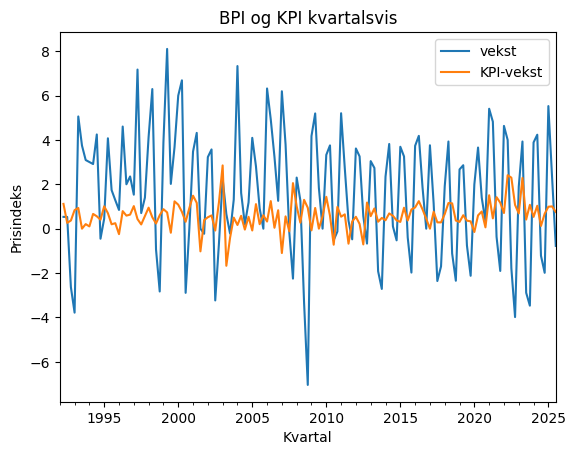

In [31]:
df[ [ "vekst", "KPI-vekst"] ].plot(title="BPI og KPI kvartalsvis")
plt.xlabel("Kvartal")
plt.ylabel("Prisindeks")

Dette plottet stadfestar skilnaden i volatilitet.
Der er stor variasjon i konsumprisindeksen, men sjelden over 2%.
Bustadprisveksten svingar mellom -7% og +8% og er ofte utanfor $\pm3$%.

Me kan sjå spreidingsplottet òg.

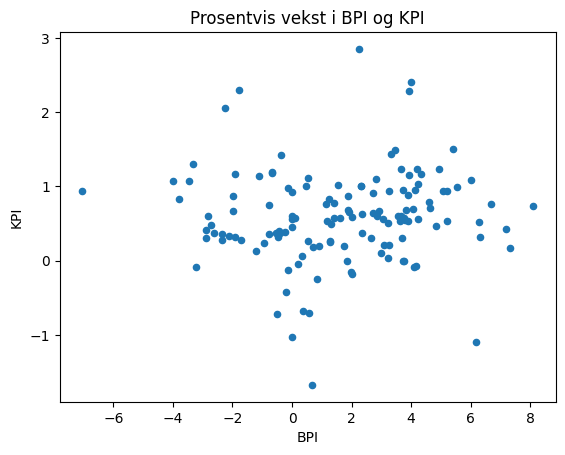

In [32]:
df.plot.scatter("vekst", "KPI-vekst")
plt.title("Prosentvis vekst i BPI og KPI")
plt.xlabel("BPI")
plt.ylabel("KPI")
plt.show()

Spreidingsplottet viser ikkje særleg korrelasjon mellom vekstratane i dei to indeksane.
Dette tyder derimot ikkje at der ikkje er korrelasjon.  Det kan tenkast at korrelasjonen er forseinka, slik at utslag i KPI t.d. får fylgjar for BPI tre eller seks månader seinare. Det har me ikkje tid til å gå inn i her.

## Avslutning og refleksjon

Analysa viser at bustadprisane i Noreg (BPI) har stige mykje frå 1992,
og har stige mykje raskare enn konsumprisindeksane (KPI).
Bustadmarknade har dermed hatt ein *reell* prisvekst samanlikna med andre
godar.
Både spreidingsplott og korrelasjonskoeffisienten viser at BPI
og KPI går isamme retning, men BPI har større volatilitet.
Det tilseier at bustadmarknaden vert påverka av fleire faktorar enn KPI.

Som student i økonomi og nylig bustadkjøpar har eg funne oppgåva
svært interessant.
Det har vore spanande å sjå kor mykje bustadprisen har stige sidan 1992.
Analysa av KPI gjev òg innsikt i korleis prisutvikling på varar og
tenester påverkar kjøpekraften, særleg no som eg sjølv skal kjøpa fleire
varar.  

I tillegg har arbeidet med oppgåva styrka programmeringskunnskapane mine.
Programmet kombinerer praktisk økonomisk forståelse med tekniske
ferdigheter, noko som er nyttig både for studium og framtidige jobb
innan økonomi og rådgjevning.

Den største utfordringa i arbeidet er å vaska datasetta og få dei på
eins leseleg form.  Det krev ein god del prøving og feiling, og
kan lett verta den største jobben i praktisk dataanalyse.
Dermed har det ikkje vore tid til å testa mange statistiske teknikkar her.
Me ser likevel at kurve- og spreidingsplott er nok til å gje god
innsikt i datasetta.
I tillegg har eg brukt korellasjon og kovarians.